In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
sns.set(style = 'darkgrid', palette = 'pastel', color_codes = True)
sns.set_context('talk')

## Causas de Valores Atipicos

1. Error de Medicion o de entrada de entadas
2. Datos vengan corruptos desde su origen
3. Realmente sea un valor atipicos (por algun acontecimiento especifico)

## Tipos de Valores Atipicos

1. **Univariante:** Observamos la distribucion de una sola variable
2. **Multivariable:** Son los valores atipicos en un espacio n-dimensional (para encontrarlos, hay que observar la distribucion muldimension)

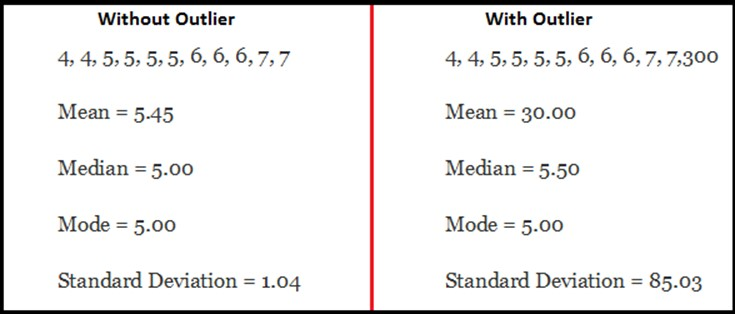

# Tecnicas Deteccion Univariante


## 1) Metodo del Rango Intercuartilico

IQR se utiliza para construir graficos de cajas y bigotes. El diagrama mide la dispersion estadistica y la variabilidad de los datos, diviendolos en cuartiles.

IQR = Q3 - Q1

  Limite Superior = Q3 + 1.5 *IQR
  
  Limite Inferior = Q1 - 1.5 *IQR

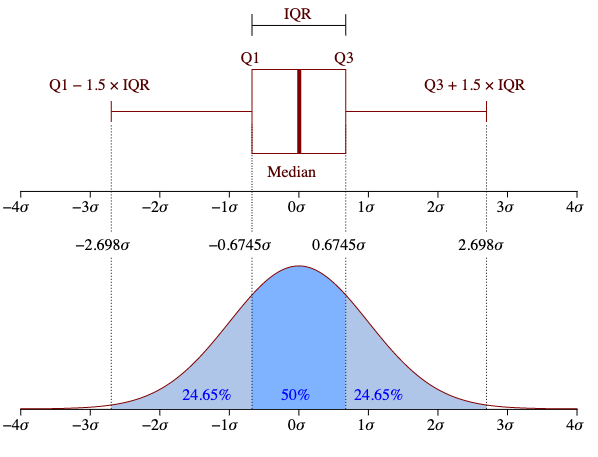

In [ ]:
df_1 = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/heart.csv')

df_1.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df_1.shape

(303, 14)

<Axes: ylabel='chol'>

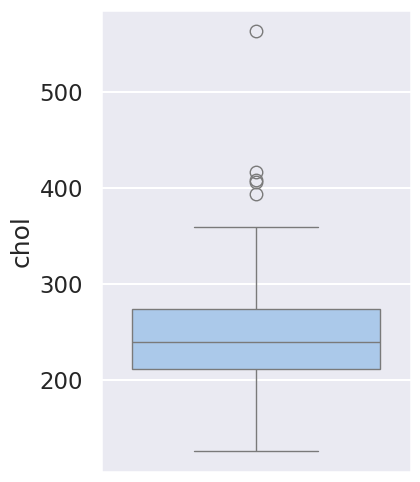

In [ ]:
# Boxplot para ver valores atipicos

plt.figure(figsize = (4, 6))
sns.boxplot(y = df_1.chol)

### Deteccion Outlier

In [ ]:
def fuera_rango_iqr(dataset, columna, factor=1.5):
    Q1 = np.quantile(dataset[columna], 0.25)
    Q3 = np.quantile(dataset[columna], 0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - factor * IQR
    lim_sup = Q3 + factor * IQR

    df1 = dataset[dataset[columna] > lim_sup]
    df2 = dataset[dataset[columna] < lim_inf]

    print(f"[{columna}] IQR: {IQR:.2f} | Inferior: {lim_inf:.2f} | Superior: {lim_sup:.2f}")
    print(f"[{columna}] Valores atípicos detectados: {df1.shape[0] + df2.shape[0]}")

    return lim_inf, lim_sup


### Visualizacion Outlier

In [ ]:
def graficar_outliers_iqr(dataset, columna, lim_inf, lim_sup):
    """
    Gráfico de histograma con zonas de valores atípicos según método IQR.
    """
    plt.figure(figsize=(10, 6))

    # Histograma con KDE para distribución
    sns.histplot(dataset[columna], kde=True, bins=30, color='skyblue')

    # Mediana
    mediana = dataset[columna].median()
    plt.axvline(x=mediana, color='blue', linestyle='--', label='Mediana')

    # Límites IQR
    plt.axvline(x=lim_inf, color='red', linestyle='--', label='Límite inferior')
    plt.axvline(x=lim_sup, color='red', linestyle='--', label='Límite superior')

    # Áreas rojas de outliers
    if dataset[columna].min() < lim_inf:
        plt.axvspan(xmin=dataset[columna].min(), xmax=lim_inf, color='red', alpha=0.2)
    if dataset[columna].max() > lim_sup:
        plt.axvspan(xmin=lim_sup, xmax=dataset[columna].max(), color='red', alpha=0.2)

    # Título y leyenda
    plt.title(f'Distribución con valores atípicos (IQR) en {columna}')
    plt.xlabel(columna)
    plt.ylabel('Frecuencia')
    plt.legend(fontsize=10, loc='upper right', frameon=True, fancybox=True, framealpha=0.8)
    plt.show()


### Filtrado (Eliminacion)  Outlier

In [ ]:
def eliminar_outliers_iqr(dataset, columna):
    inferior, superior = fuera_rango_iqr(dataset, columna)
    df_filtrado = dataset[(dataset[columna] > inferior) & (dataset[columna] < superior)]
    return df_filtrado

### Aplicacion de las Funciones (Resultado Final)

[chol] IQR: 63.50 | Inferior: 115.75 | Superior: 369.75
[chol] Valores atípicos detectados: 5


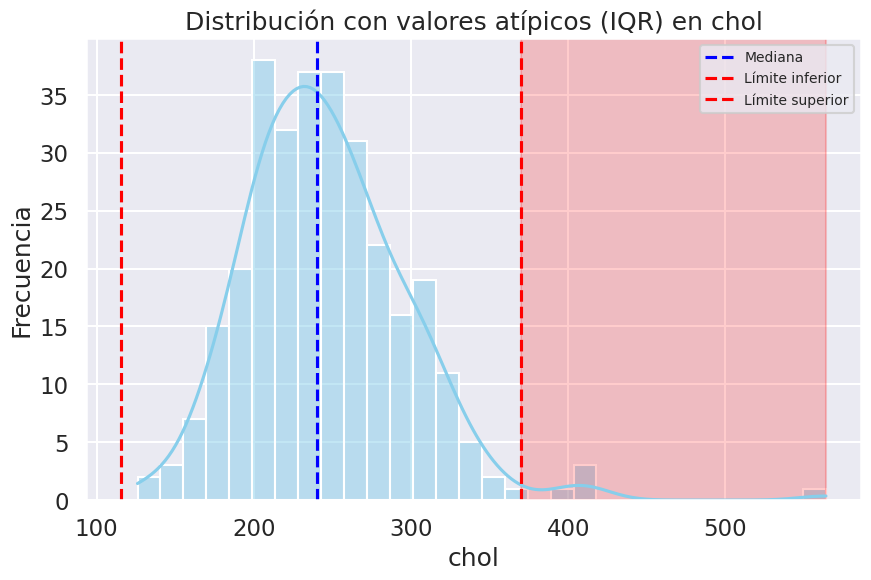

[chol] IQR: 63.50 | Inferior: 115.75 | Superior: 369.75
[chol] Valores atípicos detectados: 5
(298, 14)


In [ ]:
# Paso 1: calcular límites
inferior, superior = fuera_rango_iqr(df_1, 'chol')

# Paso 2: graficar
graficar_outliers_iqr(df_1, 'chol', inferior, superior)

# Paso 3: filtrar
df_new = eliminar_outliers_iqr(df_1, 'chol')
print(df_new.shape)


## 2) Metodo de la Desviacion Estandar

La **desviación estándar** es una medida de dispersión que indica **cuánto se alejan los datos individuales con respecto a la media**.

Cuando una variable sigue una **distribución normal**, podemos estimar qué tan inusuales son ciertos valores midiendo cuántas desviaciones estándar se encuentran alejados del promedio.

---

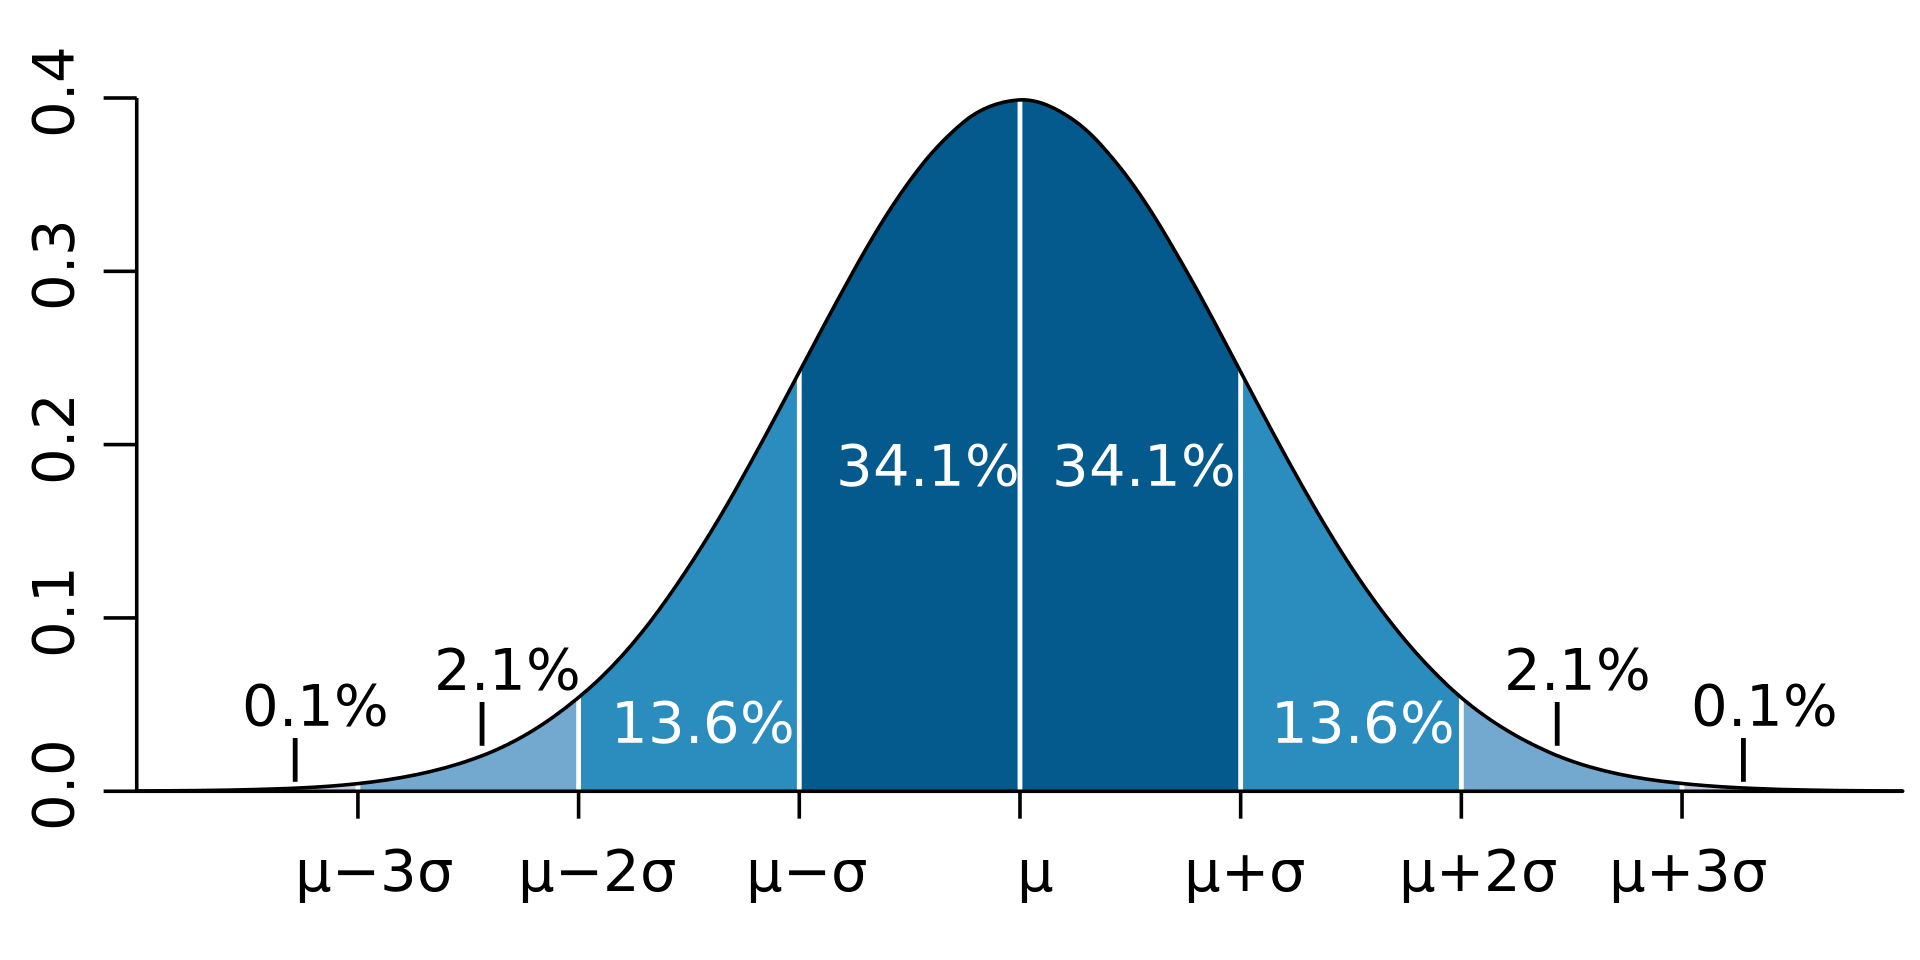

### 📊 Regla Empírica (Regla 68–95–99.7)

Si los datos tienen una forma aproximadamente normal, se cumple que:

- 📌 **68.27%** de los datos se encuentran entre **μ ± 1σ**
- 📌 **95.45%** de los datos se encuentran entre **μ ± 2σ**
- 📌 **99.73%** de los datos se encuentran entre **μ ± 3σ**

> Esto significa que los valores que caen **fuera del rango de 2 o 3 desviaciones estándar** son muy poco frecuentes y pueden considerarse **valores atípicos (outliers)**.

---

### 🎯 Criterio para detección de outliers

Un punto \( x_i \) se considera un valor atípico si **está fuera de un intervalo de confianza** definido como:

* xᵢ < μ - k · σ   
* xᵢ > μ + k · σ

Donde:

- \( µ \) es la media del conjunto de datos
- \( σ \) es la desviación estándar
- \( k \) es el número de desviaciones estándar, por ejemplo:
  - \( k = 2 \) para un intervalo del **95%**
  - \( k = 3 \) para un intervalo del **99.7%**

---

> ⚠️ **Nota:** Este método solo es recomendable si la variable analizada **tiene forma normal o casi normal**.
> Si los datos están sesgados o tienen distribución asimétrica, considera usar el **método del IQR** o **LOF**.


In [ ]:
df_2 = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/StudentsPerformance.csv')

df_2.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df_2.shape

(1000, 8)

<Axes: xlabel='writing score', ylabel='Density'>

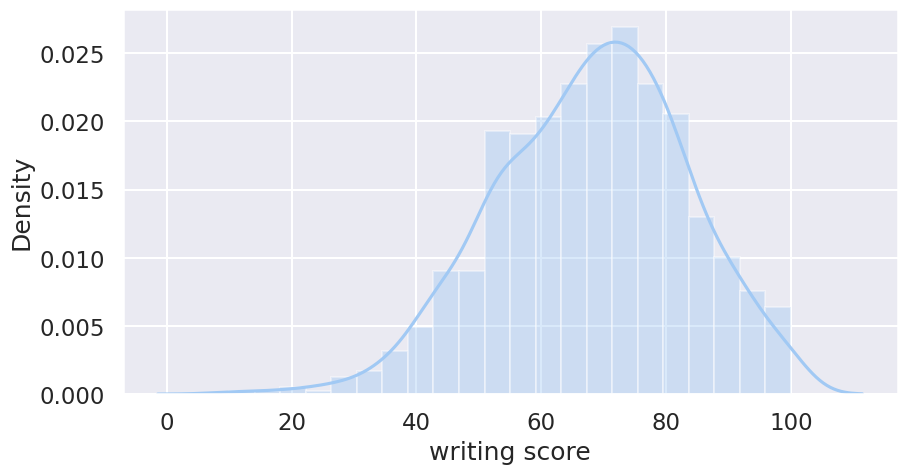

In [ ]:
# Visualizar nuestra variable #

plt.figure(figsize = (10,5))
sns.distplot(df_2['writing score'])

### Deteccion Outlier

In [ ]:
def fuera_std(dataset, columna, k=3):
    """
    Calcula los límites inferior y superior para valores atípicos
    usando el método de desviación estándar
    """
    media = dataset[columna].mean()
    std = dataset[columna].std()
    limite_inf = media - k * std
    limite_sup = media + k * std

    print(f"{columna} -> media: {media:.2f}, std: {std:.2f}")
    print(f"Límite inferior: {limite_inf:.2f}, superior: {limite_sup:.2f}")

    outliers_above = dataset[dataset[columna] > limite_sup]
    outliers_below = dataset[dataset[columna] < limite_inf]

    print(f"Total valores atípicos: {outliers_above.shape[0] + outliers_below.shape[0]}")

    return limite_inf, limite_sup

### Visualizacion Outlier

In [ ]:
def graficar_outliers_std(dataset, columna, lim_inf, lim_sup, media):
    """
    Visualiza la distribución de una variable numérica e indica los valores atípicos
    detectados mediante la técnica de desviación estándar.
    """
    plt.figure(figsize=(10, 6))

    # Graficar histograma con curva de densidad (KDE)
    sns.histplot(dataset[columna], kde=True, bins=30)

    # Línea vertical en la media
    plt.axvline(x=media, color='blue', linestyle='--', label='Media')

    #límites inferior y superior std
    plt.axvline(x=lim_inf, color='red', linestyle='--', label='Límite inferior')
    plt.axvline(x=lim_sup, color='red', linestyle='--', label='Límite superior')

    # Áreas rojas de outliers
    if dataset[columna].min() < lim_inf:
        plt.axvspan(xmin=dataset[columna].min(), xmax=lim_inf, color='red', alpha=0.2)
    if dataset[columna].max() > lim_sup:
        plt.axvspan(xmin=lim_sup, xmax=dataset[columna].max(), color='red', alpha=0.2)

    # Título y leyenda
    plt.title(f'Distribución con límites de outliers: {columna}')
    plt.legend(fontsize=10, loc='upper right', frameon=True, fancybox=True, framealpha=0.8)
    plt.show()


### Filtrado (Eliminacion)  Outlier

In [ ]:
def eliminar_outliers_std(dataset, columna, k=3):
    inferior, superior = fuera_std(dataset, columna, k)
    original_size = dataset.shape[0]
    df_filtrado = dataset[(dataset[columna] > inferior) & (dataset[columna] < superior)]
    filtrado_size = df_filtrado.shape[0]
    print(f"Se eliminaron {original_size - filtrado_size} registros fuera de [{inferior:.2f}, {superior:.2f}]")
    return df_filtrado

### Aplicacion de las Funciones (Resultado Final)

writing score -> media: 68.05, std: 15.20
Límite inferior: 22.47, superior: 113.64
Total valores atípicos: 4


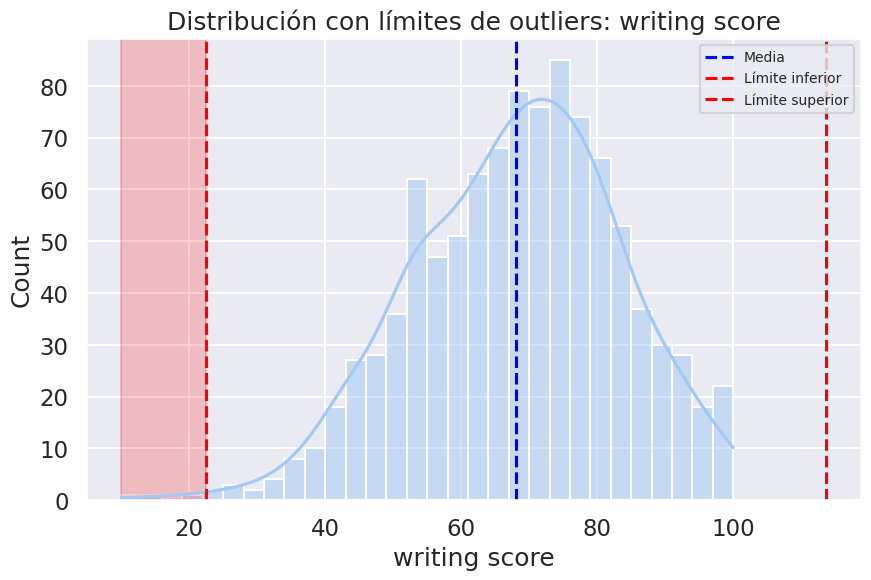

writing score -> media: 68.05, std: 15.20
Límite inferior: 22.47, superior: 113.64
Total valores atípicos: 4
Se eliminaron 4 registros fuera de [22.47, 113.64]


In [ ]:
# Paso 1: obtener límites
inf, sup = fuera_std(df_2, 'writing score', k=3)

# Paso 2: graficar distribución
graficar_outliers_std(df_2, 'writing score', inf, sup, df_2['writing score'].mean())

# Paso 3: eliminar y obtener nuevo DataFrame
df_limpio = eliminar_outliers_std(df_2, 'writing score', k=3)


## 3) Metodo de la Puntuacion Z (Valor Critico)

La puntuación Z es una técnica utilizada para detectar valores atípicos en datos **distribuidos normalmente**. Supone que los datos siguen una distribución **gaussiana o aproximadamente normal**.

Este método calcula cuántas desviaciones estándar se encuentra cada observación respecto a la media del conjunto de datos.

---

### 🎯 Criterio de detección de outliers

Se considera que un valor es atípico si su puntuación Z es muy alta (o muy baja)

Valores típicos de umbral (Z<sub>thr</sub>):

| Nivel de confianza | Z<sub>umbral</sub> | Significado |
|--------------------|--------------------|-------------|
| 90%                | 1.645              | Poco estricto |
| 95%                | 1.96               | Comúnmente usado |
| 99%                | 2.576              | Muy estricto |

---

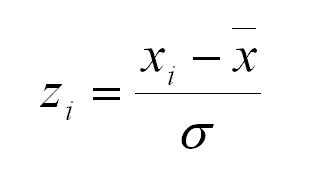

Donde:
- \( Z ): puntuación Z del dato (i)
- \( x ): valor de la observación
- \( x̅ ): media de los datos
- \( σ ): desviación estándar del conjunto

In [ ]:
# Cargar los datos #

df_3 = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/insurance.csv')

df_3.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df_3.shape

(1338, 7)

<Axes: xlabel='bmi', ylabel='Density'>

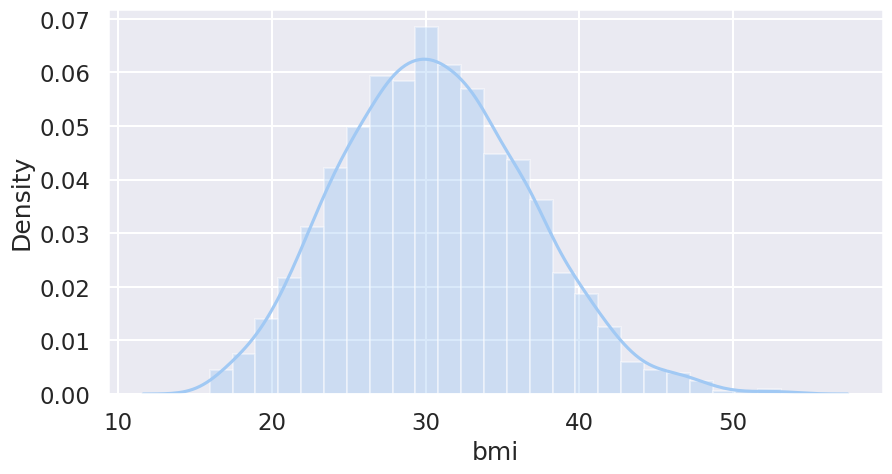

In [ ]:
# Visualizamos la informacion #
plt.figure(figsize = (10,5))
sns.distplot(df_3['bmi'])

### Deteccion Outlier

In [ ]:
def fuera_puntuacion_z(dataset, columna, umbral=2.576):
    """
    Calcula los z-scores de una columna y detecta valores atípicos
    según un umbral definido (por defecto 99% de confianza).

    Retorna los límites, los z-scores y los valores extremos.
    """
    media = dataset[columna].mean()
    std = dataset[columna].std()

    z_scores = ((dataset[columna] - media) / std).to_list()
    valores_atipicos = dataset[np.abs((dataset[columna] - media) / std) > umbral][columna].values

    print(f"[{columna}] Media: {media:.2f}, STD: {std:.2f}")
    print(f"[{columna}] Valores atípicos detectados: {len(valores_atipicos)}")

    return z_scores, valores_atipicos


### Visualizacion Outlier

In [ ]:
def graficar_zscores(z_scores, umbral):
    """
    Visualiza la distribución de las puntuaciones z y marca los límites críticos.
    """
    plt.figure(figsize=(10, 6))

    # Graficar histograma con curva de densidad (KDE) para las puntuaciones Z
    sns.histplot(z_scores, kde=True, color='skyblue')

    #límites inferior y superior segun 99% de confianza
    plt.axvline(x=umbral, color='red', linestyle='--', label='Límite superior')
    plt.axvline(x=-umbral, color='red', linestyle='--', label='Límite inferior')

    # Áreas rojas solo si hay valores más allá del umbral
    if max(z_scores) > umbral:
        plt.axvspan(xmin=umbral, xmax=max(z_scores), color='red', alpha=0.2)

    if min(z_scores) < -umbral:
        plt.axvspan(xmin=min(z_scores), xmax=-umbral, color='red', alpha=0.2)

    # Título y leyenda
    plt.title("Distribución de Z-scores con límites de outliers")
    plt.xlabel("Z-score")
    plt.ylabel("Frecuencia")
    plt.legend(fontsize=10, frameon=True, fancybox=True, framealpha=0.8)
    plt.show()


### Filtrado (Eliminacion)  Outlier

In [ ]:
def eliminar_outliers_zscore(dataset, columna, umbral=2.576):
    """
    Elimina del DataFrame los valores que tengan un z-score absoluto
    mayor al umbral especificado.
    """
    media = dataset[columna].mean()
    std = dataset[columna].std()
    z = (dataset[columna] - media) / std
    df_filtrado = dataset[np.abs(z) <= umbral]
    print(f"Filtrados {dataset.shape[0] - df_filtrado.shape[0]} valores atípicos en '{columna}'")
    return df_filtrado


### Aplicacion de las Funciones (Resultado Final)

[bmi] Media: 30.66, STD: 6.10
[bmi] Valores atípicos detectados: 14


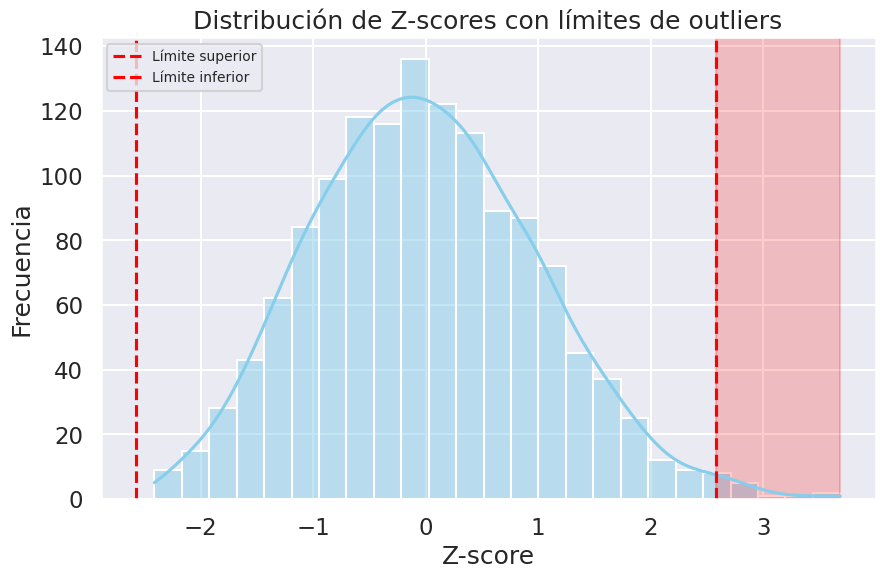

Filtrados 14 valores atípicos en 'bmi'


In [ ]:
# Detectar z-scores y valores atípicos
z_scores, valores_outliers = fuera_puntuacion_z(df_3, 'bmi', umbral=2.576)

# Graficar
graficar_zscores(z_scores, umbral=2.576)

# Eliminar del dataset
df_limpio = eliminar_outliers_zscore(df_3, 'bmi', umbral=2.576)


## 4) Bosque de Aislamiento

Dividir los datos utilizando un conjunto de arboles, con el objetivo de proporcionar una puntuacion de anomalia que se observa que tan aislado esta el punto (valor) en la estructura encontrada.

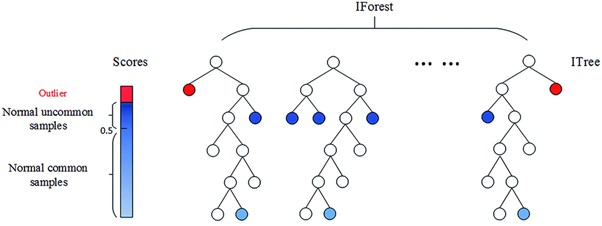

1. El arbol selecciona aleatoriamente un punto "a" para aislar.
2. Luego selecciona un punto aleatorio "b" que esta entre el minimo y el maximo diferentes de "a".
3. Si el valor "b" es inferior al valor de "a" se convierte en mi nuevo limite inferior.
4. Si el valor "b" es mayor que el valor de "a" se convierte en mi nuevo limite superior.
5. Este proceso se repite siempre que haya puntos distintos de "a" entre limite superior e inferior.

In [ ]:
df_4 = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/StudentsPerformance.csv')

df_4.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df_4.shape

(1000, 8)

### Deteccion Outlier

In [ ]:
def detectar_outliers_isolation(df, columnas, contamination=0.05, random_state=123):
    """
    Detecta outliers en una o más columnas, añade columnas auxiliares *_outlier y *_score.
    """
    if isinstance(columnas, str):
        columnas = [columnas]

    df_resultado = df.copy()

    for col in columnas:
        modelo = IsolationForest(contamination=contamination, random_state=random_state)
        modelo.fit(df[[col]])
        df_resultado[f"{col}_outlier"] = modelo.predict(df[[col]])
        df_resultado[f"{col}_score"] = modelo.decision_function(df[[col]])

    return df_resultado



### Visualizacion Outlier

In [ ]:
def graficar_isolation(df_resultado, columnas):
    """
    Visualiza los outliers detectados por Isolation Forest como puntos,
    resaltando los valores atípicos con un color diferente.
    """
    if isinstance(columnas, str):
        columnas = [columnas]

    for col in columnas:
        score_col = f"{col}_score"
        outlier_col = f"{col}_outlier"

        if score_col not in df_resultado.columns or outlier_col not in df_resultado.columns:
            print(f"[{col}] no tiene columnas auxiliares generadas con Isolation Forest.")
            continue

        plt.figure(figsize=(10, 5))

        # Colores según si es outlier o no
        colores = df_resultado[outlier_col].map({1: 'skyblue', -1: 'red'})

        # Scatter: notas en X, puntuación en Y
        plt.scatter(df_resultado[col], df_resultado[score_col],
                    c=colores, s=40, edgecolor='black', alpha=0.7)

        plt.title(f"Puntuación anómala vs. valor real - {col}")
        plt.xlabel(f"{col}")
        plt.ylabel("Puntuación anómala (score)")
        plt.grid()
        plt.tight_layout()
        plt.show()


### Filtrado (Eliminacion)  Outlier

In [ ]:
def filtrar_outliers_isolation(df, columnas, conservar_columnas_aux=False):
    """
    Elimina del DataFrame todas las filas consideradas outliers en cualquiera de las columnas especificadas.
    """
    if isinstance(columnas, str):
        columnas = [columnas]

    df_filtrado = df.copy()

    for col in columnas:
        col_out = f"{col}_outlier"
        if col_out not in df_filtrado.columns:
            raise ValueError(f"La columna {col_out} no existe. Asegurate de haber ejecutado la detección.")

        df_filtrado = df_filtrado[df_filtrado[col_out] == 1]

    if not conservar_columnas_aux:
        cols_a_borrar = [f"{col}_outlier" for col in columnas] + [f"{col}_score" for col in columnas]
        df_filtrado = df_filtrado.drop(columns=cols_a_borrar)

    print(f"Filtrado completo. Filas restantes: {df_filtrado.shape[0]}")
    return df_filtrado


### Aplicacion de las Funciones (Resultado Final)

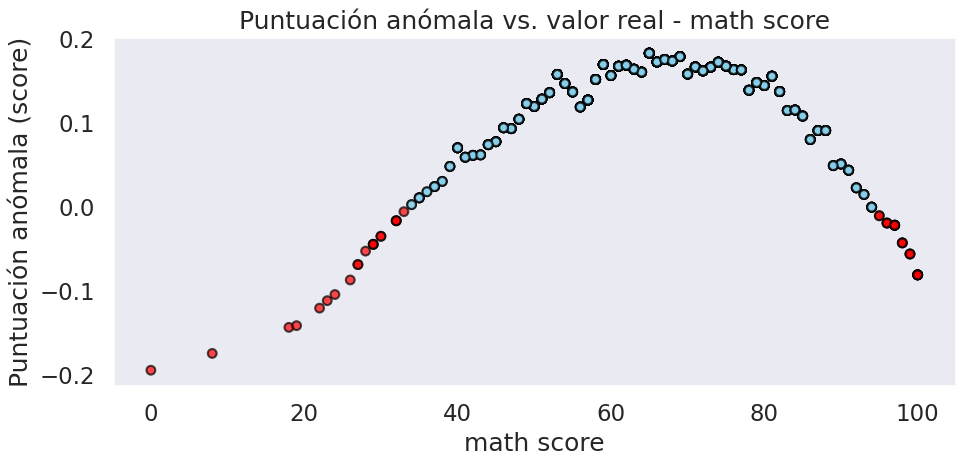

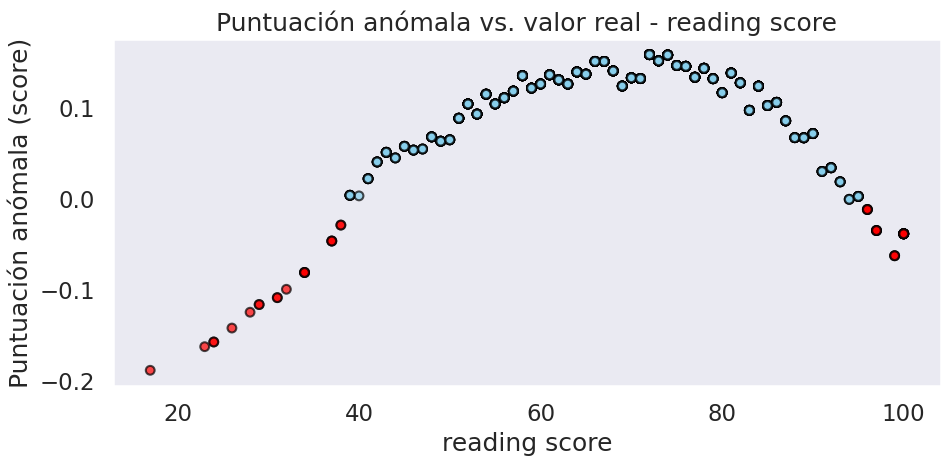

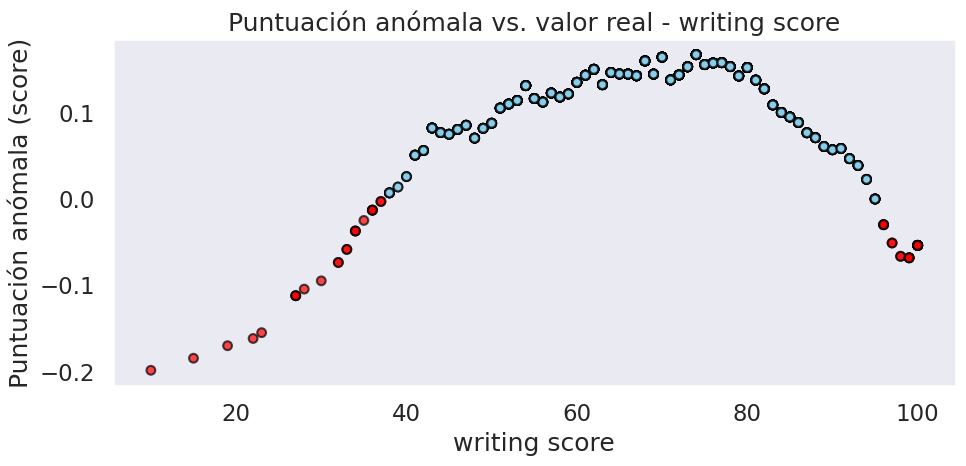

Filtrado completo. Filas restantes: 924


In [ ]:
# Paso 0: Definir las columnas a evaluar
columnas = ['math score', 'reading score', 'writing score']

# Paso 1: Detectar outliers y calcular el score anómalo
df_con_outliers = detectar_outliers_isolation(df_4, columnas, contamination=0.05)

# Paso 2: Visualizar los resultados
graficar_isolation(df_con_outliers, columnas)

# Paso 3: Filtrar los datos eliminando outliers detectados
df_limpio = filtrar_outliers_isolation(df_con_outliers, columnas, conservar_columnas_aux=False)

# Valores Atipicos Multivariados

## 1) DBSCAN(Densidad/ Basada en Aplicacion a Cluster Espacial con Ruido)

**DBSCAN** es un algoritmo de agrupamiento (clustering) que **agrupa puntos que están cercanos entre sí** según una densidad definida.  
A diferencia de otros algoritmos como K-Means, **no necesita saber cuántos grupos (clusters) habrá**, y **detecta valores atípicos (outliers)** de forma natural.

---

### 🤓 ¿Cómo funciona?

DBSCAN se basa en dos parámetros clave:

- 📏 **ε (epsilon):** radio de vecindad. Define qué tan cerca deben estar los puntos para considerarse "vecinos".
- 🔢 **min_samples:** número mínimo de puntos vecinos que debe tener un punto para formar un "núcleo" (core).

---

### 🧩 Clasificación de puntos:

- 🟢 **Punto Núcleo (core):** tiene al menos `min_samples` dentro del radio `ε`.
- 🟡 **Punto Frontera (border):** está dentro del radio de un núcleo, pero no tiene suficientes vecinos para ser núcleo.
- 🔴 **Ruido (outlier):** no pertenece a ningún cluster. Es un punto aislado.

---

### 🎯 ¿Por qué usar DBSCAN para detectar outliers?

- Identifica automáticamente **zonas densas** y separa los puntos **aislados como valores atípicos**.
- No necesita conocer el número de clusters de antemano.
- Funciona bien con clusters de formas arbitrarias (no solo esferas como K-means).
- Detecta **outliers espaciales** que están lejos del resto.

---

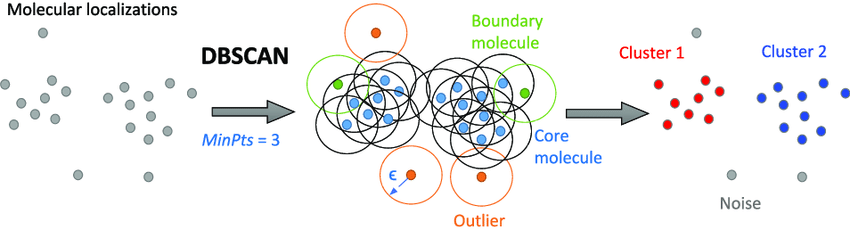

### 🧠 Interpretación visual

En la imagen, los puntos:

- 🔵 Son núcleos (core points)
- 🟢 Son fronteras (`border points`)
- 🔴 Serían ruido (outliers), no agrupados en ningún cluster

---

> ⚠️ **Nota:** Es importante escalar las variables antes de aplicar DBSCAN para que todas tengan la misma influencia al calcular distancias.

In [ ]:
# Cargar los datos #

df_5 = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/insurance.csv')

df_5.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df_5.shape

(1338, 7)

### Deteccion Outlier

In [ ]:
def detectar_outliers_dbscan(df, columnas, eps=0.5, min_samples=5):
    """
    Aplica DBSCAN para detectar outliers multivariables en las columnas seleccionadas.
    """
    df_resultado = df.copy()

    # Escalar las variables seleccionadas
    X = df_resultado[columnas].values
    X_scaled = StandardScaler().fit_transform(X)

    # Aplicar DBSCAN
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
    etiquetas = db.labels_  # -1 = outlier, 0 o más = cluster

    df_resultado['dbscan_outlier'] = etiquetas
    return df_resultado


### Visualizacion Outlier

In [ ]:
def graficar_dbscan_2d(df, columnas, etiqueta_col='dbscan_outlier'):
    """
    Visualiza los resultados de DBSCAN para dos variables numéricas.
    """
    if len(columnas) != 2:
        raise ValueError("Para graficar DBSCAN en 2D, debes seleccionar exactamente dos columnas.")

    X = df[columnas].values
    etiquetas = df[etiqueta_col].values

    plt.figure(figsize=(10, 6))
    colores = { -1: 'red', 0: 'blue', 1: 'green', 2: 'purple', 3: 'orange' }

    for etiqueta in set(etiquetas):
        mascara = etiquetas == etiqueta
        plt.scatter(X[mascara, 0], X[mascara, 1],
                    c=colores.get(etiqueta, 'gray'),
                    label='Outlier' if etiqueta == -1 else f'Cluster {etiqueta}',
                    edgecolor='black', alpha=0.7, s=60)

    plt.xlabel(columnas[0])
    plt.ylabel(columnas[1])
    plt.title("Clusters y Outliers detectados con DBSCAN")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=9)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Filtrado (Eliminacion)  Outlier

In [ ]:
def filtrar_outliers_dbscan(df, outlier_col='dbscan_outlier', conservar_columna=False):
    """
    Elimina los registros considerados outliers según DBSCAN (-1).
    """
    df_filtrado = df[df[outlier_col] != -1].copy()
    if not conservar_columna:
        df_filtrado = df_filtrado.drop(columns=[outlier_col])
    print(f"Filtrado completo. Filas restantes: {df_filtrado.shape[0]}")
    return df_filtrado


### Aplicacion de las Funciones (Resultado Final)

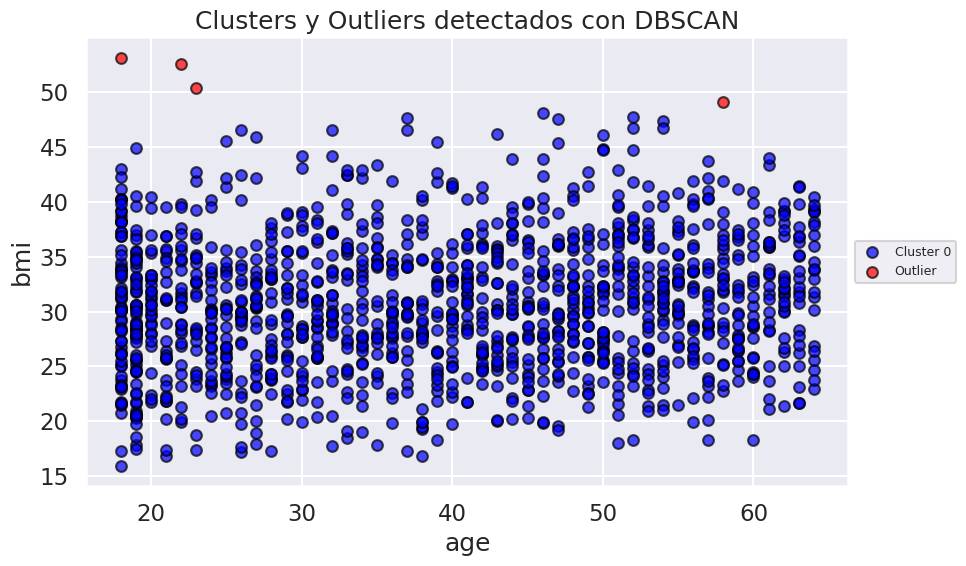

Filtrado completo. Filas restantes: 1334


In [ ]:
# Paso 0: Definir las variables a usar (solo 2 si vas a graficar)
columnas_dbscan = ['age', 'bmi']

# Paso 1: Detectar outliers con DBSCAN
df_dbscan = detectar_outliers_dbscan(df_5, columnas=columnas_dbscan, eps=0.5, min_samples=10)

# Paso 2: Visualizar resultados en 2D
graficar_dbscan_2d(df_dbscan, columnas=columnas_dbscan)

# Paso 3: Filtrar registros normales
df_dbscan_limpio = filtrar_outliers_dbscan(df_dbscan)


## 2) METODO LOF (Factor Atipico Local)

El algoritmo **LOF (Factor Atípico Local)** es una técnica basada en densidad que permite **detectar outliers comparando cada punto con su vecindario más cercano**.

---

### 🤓 ¿Cómo funciona?

LOF no evalúa la rareza de un dato de forma global (como el Z-score o la desviación estándar), sino que:

1. Evalúa la **densidad local** alrededor de un punto.
2. La compara con la densidad de sus vecinos cercanos.
3. Si un punto tiene una densidad significativamente menor que la de sus vecinos, es considerado un **outlier local**.

---

### 🔢 ¿Qué significa el valor LOF?

- LOF ≈ **1** → comportamiento **normal**, similar al entorno
- LOF > **1.5** → comportamiento **atípico**, baja densidad en comparación con vecinos
- LOF >> **2.0** → **outlier fuerte**

---

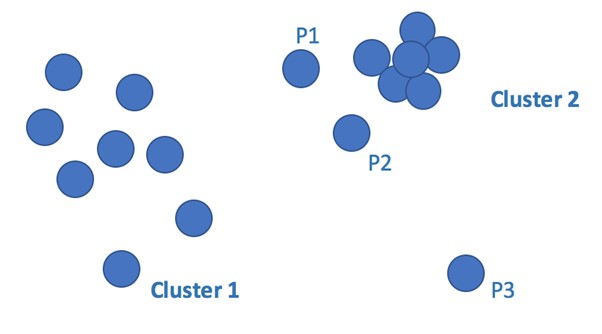

### 📍 Interpretación visual:

En la imagen:

- 🔵 **P1 y P2** están en zonas densas, forman parte de sus respectivos clusters.
- 🔵 **P3**, en cambio, **está alejado de cualquier grupo denso** → LOF alto → **outlier local**.

El algoritmo considera **la relación entre la densidad de un punto y la densidad de sus vecinos**, no solo su distancia.

---

### 🎯 ¿Por qué usar LOF?

- 📌 Detecta **outliers contextuales**: valores que son normales globalmente, pero extraños **localmente**.
- 📌 No asume distribución normal ni forma esférica.
- 📌 Ideal cuando los datos tienen **clusters con diferentes densidades**.

---

> 💡 **Ejemplo:** en una base médica, un paciente puede parecer "normal" respecto a toda la muestra, pero **muy diferente dentro de su grupo de edad y género**. LOF lo detectaría como atípico **localmente**, mientras otros métodos no.

In [ ]:
df_6 = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/heart.csv')

df_6.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df_6.shape

(303, 14)

### Deteccion Outlier

In [ ]:
def detectar_outliers_lof(df, columnas, n_neighbors=50, contamination='auto'):
    """
    Detecta outliers usando Local Outlier Factor (LOF) en múltiples columnas.
    """
    df_resultado = df.copy()

    X = df[columnas].values
    X_scaled = StandardScaler().fit_transform(X)

    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    etiquetas = lof.fit_predict(X_scaled)  # 1 = normal, -1 = outlier
    scores = lof.negative_outlier_factor_

    df_resultado['lof_outlier'] = etiquetas
    df_resultado['lof_score'] = scores
    return df_resultado


### Visualizacion Outlier

In [ ]:
def graficar_lof_2d(df, columnas, etiqueta_col='lof_outlier'):
    """
    Visualiza en 2D los outliers detectados con LOF.
    """
    if len(columnas) != 2:
        raise ValueError("Para graficar LOF en 2D, debes seleccionar exactamente dos columnas.")

    X = df[columnas].values
    etiquetas = df[etiqueta_col].values

    plt.figure(figsize=(10, 6))
    dentro = etiquetas == 1
    fuera = etiquetas == -1

    plt.scatter(X[dentro, 0], X[dentro, 1], c='skyblue', edgecolor='k', s=30, label='Normales')
    plt.scatter(X[fuera, 0], X[fuera, 1], c='red', edgecolor='k', s=40, label='Outliers')

    plt.xlabel(columnas[0])
    plt.ylabel(columnas[1])
    plt.title('Detección de valores atípicos con LOF')
    plt.legend(loc='best', fontsize=9, frameon=True, fancybox=True)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Filtrado (Eliminacion)  Outlier

In [ ]:
def filtrar_outliers_lof(df, conservar_columnas_aux=False):
    """
    Elimina los outliers detectados por LOF del DataFrame.
    """
    df_filtrado = df[df['lof_outlier'] == 1].copy()

    if not conservar_columnas_aux:
        df_filtrado = df_filtrado.drop(columns=['lof_outlier', 'lof_score'])

    print(f"Filtrado completo. Filas restantes: {df_filtrado.shape[0]}")
    return df_filtrado


### Aplicacion de las Funciones (Resultado Final)

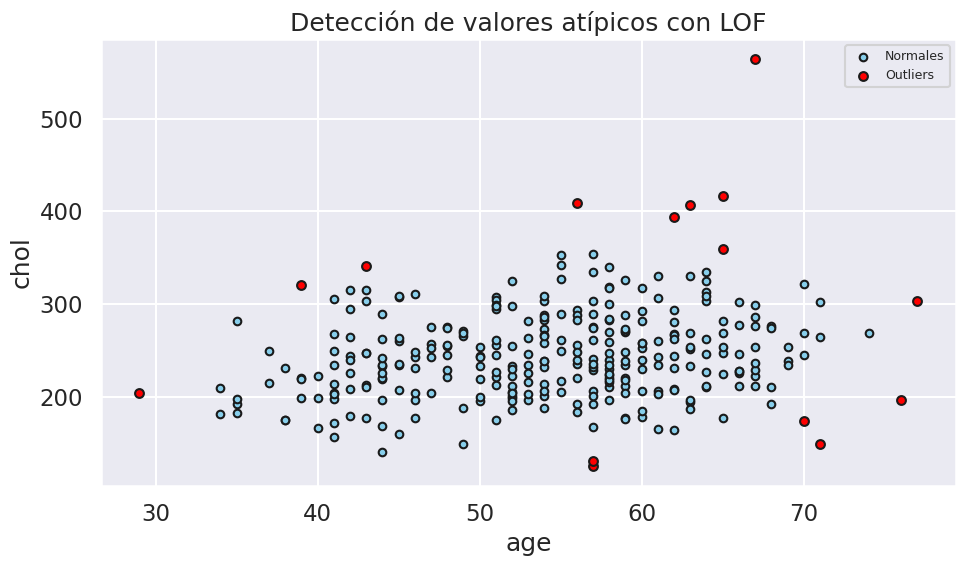

Filtrado completo. Filas restantes: 288


In [ ]:
# Paso 0: Definir las variables a analizar
columnas_lof = ['age', 'chol']

# Paso 1: Detectar outliers con LOF
df_lof = detectar_outliers_lof(df_6, columnas=columnas_lof, n_neighbors=50, contamination='auto')

# Paso 2: Visualizar los outliers (2D)
graficar_lof_2d(df_lof, columnas=columnas_lof)

# Paso 3: Filtrar datos normales (quitar outliers)
df_lof_limpio = filtrar_outliers_lof(df_lof, conservar_columnas_aux=False)
